In [1]:
import sys

import vis_plotting as vis_plt
import EAVILS_processing
import my_utils
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import matplotlib_venn 
from matplotlib.patches import Circle


import scipy
import os
import yaml
import copy
import pandas as pd
import bidict

import astropy.io.fits as fits
from astropy.coordinates import Angle
from astropy import units as u
from astropy.time import Time



## This tutorial walks through how to generate parameters for the EAVILS pol-subtracted metric, and introduces methods for identifying RFI using this metric.

# Initial parameters

In [2]:


#Flagging the coarse band lines for the MWA. In general this parameter can be used for flagging coarse-band lines,
#or things like known FM or satellite contaminated channels
permanent_flags = my_utils.coarse_band_flagging()

#This shape_dict is taken from SSINS, with an additional "subTV" pseudo-channel added as a control "clean channel". 
#This subTV channel is quite simply the frequencies below which the digital TV channels live
shape_dict = my_utils.shape_dict('MWA',add_subTV=True)
#We only want TV channels, so we remove the 'center_packet_loss' frequency type
del shape_dict['center_packet_loss']
print(shape_dict)
#This quite simply sorts our frequency channels based on their minimum frequency
sorted_freq_ranges,sorted_freq_mins = EAVILS_processing.freq_range_sort(shape_dict)
#Establishes the correspondence between polarizations and polarization indices
pol_bidict = bidict.bidict({0:'XX',1:'YY',2:'XY',3:'YX'})


{'TV6': [174000000.0, 181000000.0], 'TV7': [181000000.0, 188000000.0], 'TV8': [188000000.0, 195000000.0], 'TV9': [195000000.0, 202000000.0], 'subTV': [167075000.0, 174000000.0]}


# Iniitial Processing

## This section shows how to process raw files (e.g. uvfits files) into data usable for EAVILS. It includes example calls but doesn't actually process data due to raw files being prohibitively large

### This processing step reduces the data volume massively by compressing along baselines.

### This step will not process data without downloading the raw (e.g. uvfits) file to process it with. As it stands it should just return a message that the file already exists
We dont't include the raw files (in this case UVfits files and metafits files), and simply shows one example obs_id, but in general all desired data should be processed in this way as an initial step. The output data for this obs_id is included on the github as an example.

In [3]:
all_obs_id_list = ['1160938096','1160938216','1160938344','1160938464']
raw_data_folder = '<raw_data/in/this/folder>'

for obs_id in all_obs_id_list:
    vis_plt.vis_plotting(obs_id = obs_id,input_data_folder=raw_data_folder,output_path='testing_tutorial/',extension='uvfits')

OUTPUT CHECKING; found testing_tutorial/h5_files/1160938096_spectra_data_cross.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938216_spectra_data_cross.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938344_spectra_data_cross.h5, bypassing spectra outputs
OUTPUT CHECKING; found testing_tutorial/h5_files/1160938464_spectra_data_cross.h5, bypassing spectra outputs


### The input directory should be set to the output_path of vis_plotting, in the h5_files subdirectory. Again, here we just have one example file in this folder, but if the previous step is executed on a set of raw files, this directory should contain the EAVILS h5 files generated above

In [4]:
input_directory = '<output/path/for/h5/files>'


List files are text lists of observations that are used to divide the observations into per-night, per-sky-field chunks, necessary for later data processign

In [5]:

list_file_directory = 'example_obs_lists'

In [6]:
#Establishing which data is in the EOR0 and EOR1 sky fields

EOR0_lists = []
EOR1_lists = []
for file in os.listdir(list_file_directory):
    if 'EOR0' in file:
        EOR0_lists.append(file)
    elif 'EOR1' in file:
        EOR1_lists.append(file)


all_lists =  EOR0_lists+EOR1_lists
all_lists = sorted(all_lists)

list_titles = [file.split('.')[0] for file in os.listdir(list_file_directory) if len(file.split('.')[0] )>0]
list_titles = sorted(list_titles)
sky_field_list = ['EOR0','EOR1']
sky_field_list_association = {list_file.split('.')[0]:'EOR0' for list_file in EOR0_lists}
sky_field_list_association.update({list_file.split('.')[0]:'EOR1' for list_file in EOR1_lists})

### Again, we dont't include the per-observation EAVILS files on the github due to size constraints. We include this call as an example. The following step has already been run and generated output files. It requires the data processed by vis_plt.vis_plotting above to run from scratch. It should just return messages saying the files already exist.
We need to set the time and frequency dimensions of the averaging. 

When the number of times or frequencies doesn't divide evenly by the dimensions, the remaining data will be averaged into the maximum possible chunk size.

It's not currently recommended to use a freq_dim other than 1 for MWA data

Note that without generating more per-observation data using vis_plt.vis_plotting above, one shouldn't alter the time_dim parameter, because the generated files already exist

In [7]:

time_dim = 8 #Number of integrations averaged across
freq_dim = 1 #Number of frequency channels averaged across

In [8]:
metafits_folder = '<path/to/metafits>' #Needed for pointing information for the MWA
for list_file in all_lists:
    
    list_title=list_file.split('.txt')[0]
    list_file = f'{list_file_directory}/{list_file}'
    print(list_title, list_file)
    EAVILS_processing.process_data(list_file=list_file,
                                   input_directory=input_directory,
                                   output_directory='testing_tutorial',
                                   time_dim=time_dim,
                                   freq_dim=freq_dim,
                                   pol_bidict=pol_bidict,
                                   shape_dict=shape_dict,
                                   permanent_flags=permanent_flags,
                                   metafits_folder=metafits_folder,
                                   pre_flag_on_SSINS_masks=True,
                                   clobber=False, 
                                   allowed_missing_fraction=0.1)

10-15-2016-EOR0 example_obs_lists/10-15-2016-EOR0.txt
Output file testing_tutorial/10-15-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-15-2016-EOR1 example_obs_lists/10-15-2016-EOR1.txt
Output file testing_tutorial/10-15-2016-EOR1/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-17-2016-EOR0 example_obs_lists/10-17-2016-EOR0.txt
Output file testing_tutorial/10-17-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-17-2016-EOR1 example_obs_lists/10-17-2016-EOR1.txt
Output file testing_tutorial/10-17-2016-EOR1/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Exiting function. Change clobber to True to overwrite existing file.
10-19-2016-EOR0 example_obs_lists/10-19-2016-EOR0.txt
Output file testing_tutorial/10-19-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already e

# Turning processed EAVILS data into pol-subtracted data

### With our processed data in hand, we can generate pol-subtracted metric values. From here on, all necessary data is on the github.

In [9]:
processed_data_directory = 'testing_tutorial/'


In [10]:
#Establishes the order in which polarizations should be subtracted
pol_subtraction_order = {(0,1),(1,0),(2,3),(3,2)}

In [11]:
#Reads processed data in, generating numpy arrays in a dictionary with 
array_dict, dof_ref_dict,sky_field_dict,source_list_dict,pointing_info_dict = EAVILS_processing.create_data_arrays(processed_data_directory = processed_data_directory,
                                                                                                                   list_titles=list_titles,
                                                                                                                   time_dim=time_dim,
                                                                                                                   freq_dim=freq_dim,
                                                                                                                   shape_dict=shape_dict,
                                                                                                                   sky_field_list_association=sky_field_list_association,
                                                                                                                   pol_subtraction_order=pol_subtraction_order)

creating data arrays
10-15-2016-EOR0
10-15-2016-EOR1
10-17-2016-EOR0
10-17-2016-EOR1
10-19-2016-EOR0
10-19-2016-EOR1
10-21-2016-EOR0
10-21-2016-EOR1
10-22-2016-EOR0
10-22-2016-EOR1
10-26-2016-EOR0
10-26-2016-EOR1
10-28-2016-EOR0
10-28-2016-EOR1
10-30-2016-EOR0
10-30-2016-EOR1
11-12-2016-EOR0
11-17-2016-EOR0
11-19-2016-EOR0
11-21-2016-EOR0
12-15-2016-EOR0


The array_dict has the following entries

In [12]:
array_dict.keys()

dict_keys(['variance', 'reshaped_SSINS_mask', 'pol_sub'])

Arrays have dimensions of (no. of time chunks, no. of freq. ranges, no. of polarizations/polarization subtraction pairs)
For pol_sub data, the first polarization subtraction pair entry is the only one used later on, this is the XX-YY pair. The second entry is simply YY-XX instead of XX-YY, and third and fourth XY-YX and YX-XY.

In [13]:
example_obs_id = '1160938096'
#Example dimensions
array_dict['pol_sub'][example_obs_id].shape

(7, 5, 4)

Here we put our data into a dataframe for easy referencing, including some important metadata for each entry. This returns a pandas dataframe which collects the important data for each measurement into a single pandas dataframe. In other words, for each frequency and time, there is a row with all the input data.

In [31]:

datafr = EAVILS_processing.create_data_frame(pol_bidict=pol_bidict,
                                             shape_dict=shape_dict,
                                             array_dict=array_dict,
                                             sky_field_dict=sky_field_dict,
                                             source_list_dict=source_list_dict,
                                             pointing_info_dict=pointing_info_dict)

In [15]:
datafr

,obs_id,sky_field,t_block_ind,pointing,pol_sub,SSINS_flagged,pol_sub_flagged,pointing_flagged,source_list,variance_XX,variance_YY,variance_XY,variance_YX,freq_range
0,1160570624,EOR0,0,-3,0.056206,False,False,False,10-15-2016-EOR0,0.930479,0.874273,1.165698,0.805516,subTV
1,1160570624,EOR0,1,-3,-0.116945,False,False,False,10-15-2016-EOR0,0.833844,0.950789,0.945145,0.821371,subTV
2,1160570624,EOR0,2,-3,-0.243281,False,False,False,10-15-2016-EOR0,0.796385,1.039666,0.869899,0.716439,subTV
3,1160570624,EOR0,3,-3,0.256630,False,False,False,10-15-2016-EOR0,0.952791,0.696161,0.715759,0.611471,subTV
4,1160570624,EOR0,4,-3,-0.009160,False,False,False,10-15-2016-EOR0,0.998318,1.007478,0.792041,1.004227,subTV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58970,1165836936,EOR0,2,2,-2.370354,True,False,False,12-15-2016-EOR0,7.224489,9.594843,9.950595,9.690604,TV9
58971,1165836936,EOR0,3,2,-0.423316,True,False,False,12-15-2016-EOR0,9.418619,9.841935,10.056358,10.784077,TV9
58972,1165836936,EOR0,4,2,-1.149243,True,False,False,12-15-2016-EOR0,10.154446,11.303689,11.165458,9.820784,TV9
58973,1165836936,EOR0,5,2,-3.124421,True,False,False,12-15-2016-EOR0,8.476300,11.600721,11.029293,10.066346,TV9


## Estimating standard deviation for pol-subtracted metric

### In general its really important to get this step right. We go through the process of finding clean data to use as an initial guess for the standard deviation, and then how to get a better estimate

### Generate plots like the below for a handful of nights. Identify any sections of data that have COWs as seen in the XX polarization here.

Using default plot_instructions:[('EAVILS', 'XX', 'raster', 1), ('SSINS', 'XX', 'raster', 1), ('EAVILS', 'YY', 'raster', 1), ('SSINS', 'YY', 'raster', 1), ('SSINS mask', 'XX', 'raster', 1)]
pointing = 1
1160938096
1160938216
1160938344
1160938464
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1restricted_ptng_1_EAVILS.pdf


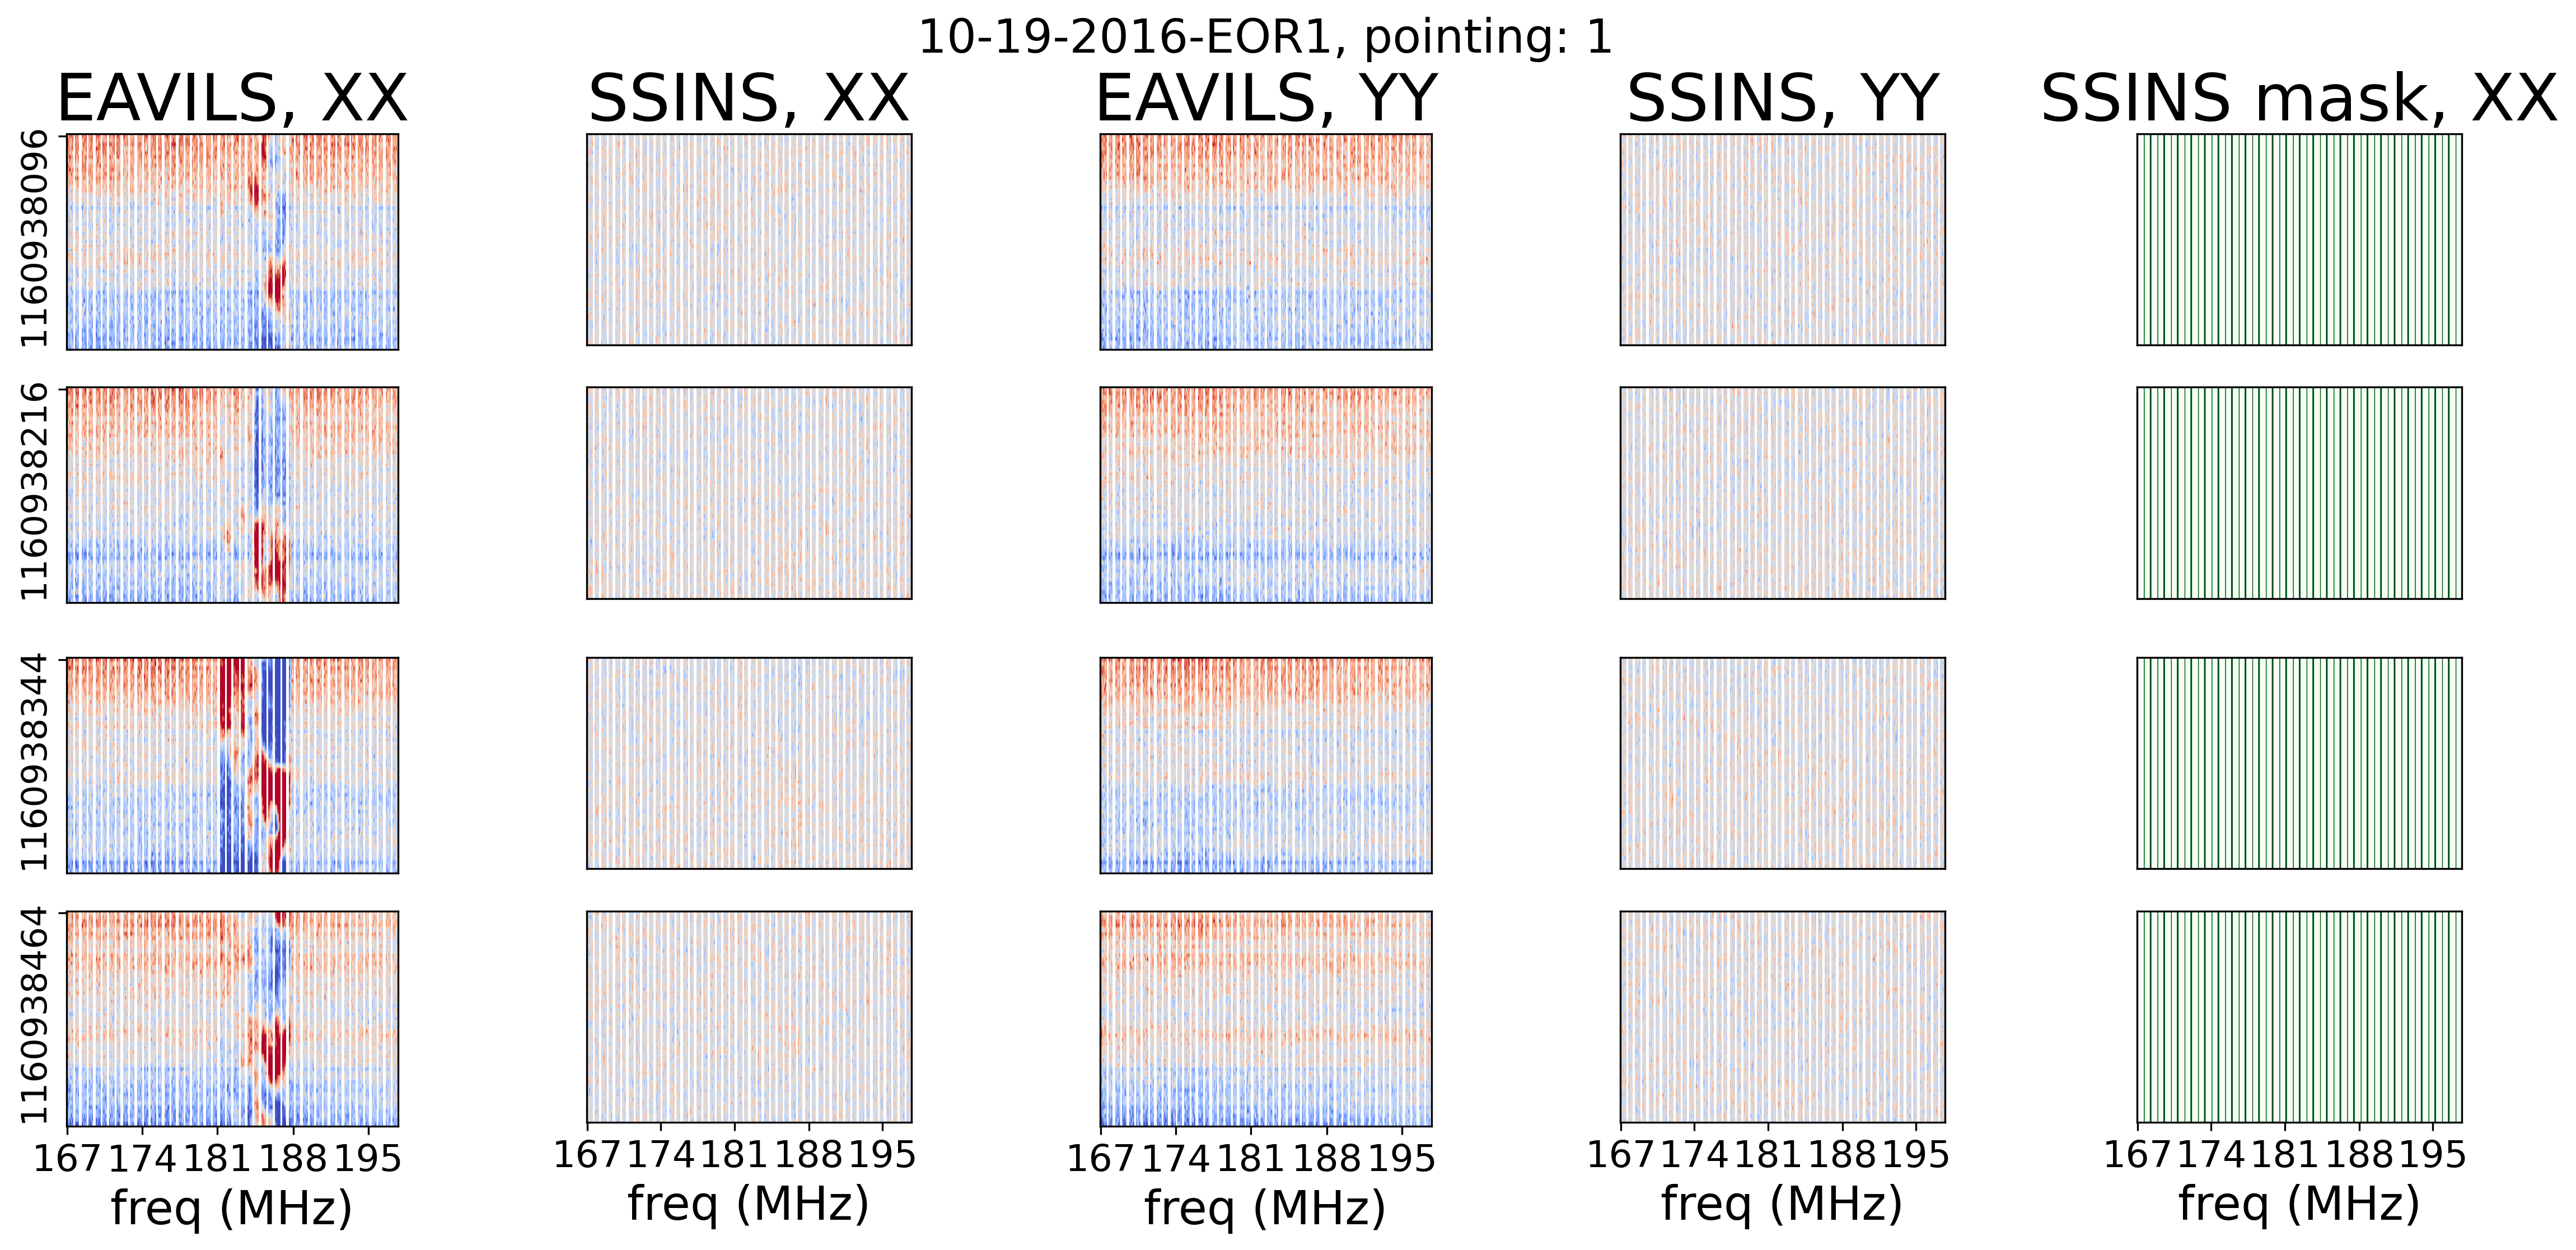

In [16]:


integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists/10-19-2016-EOR1.txt',
                               array_dict=array_dict,
                               dof_ref_dict = dof_ref_dict,
                               input_directory='testing_tutorial/h5_files/',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pointing_info_dict=pointing_info_dict,
                               pol_bidict=pol_bidict,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               restricted_list=['1160938096','1160938216','1160938344','1160938464'],
                               show=True
                              )

Next we add manually graded data from a csv (as well as chi-squared and SSINS flags for making a comparison plot)

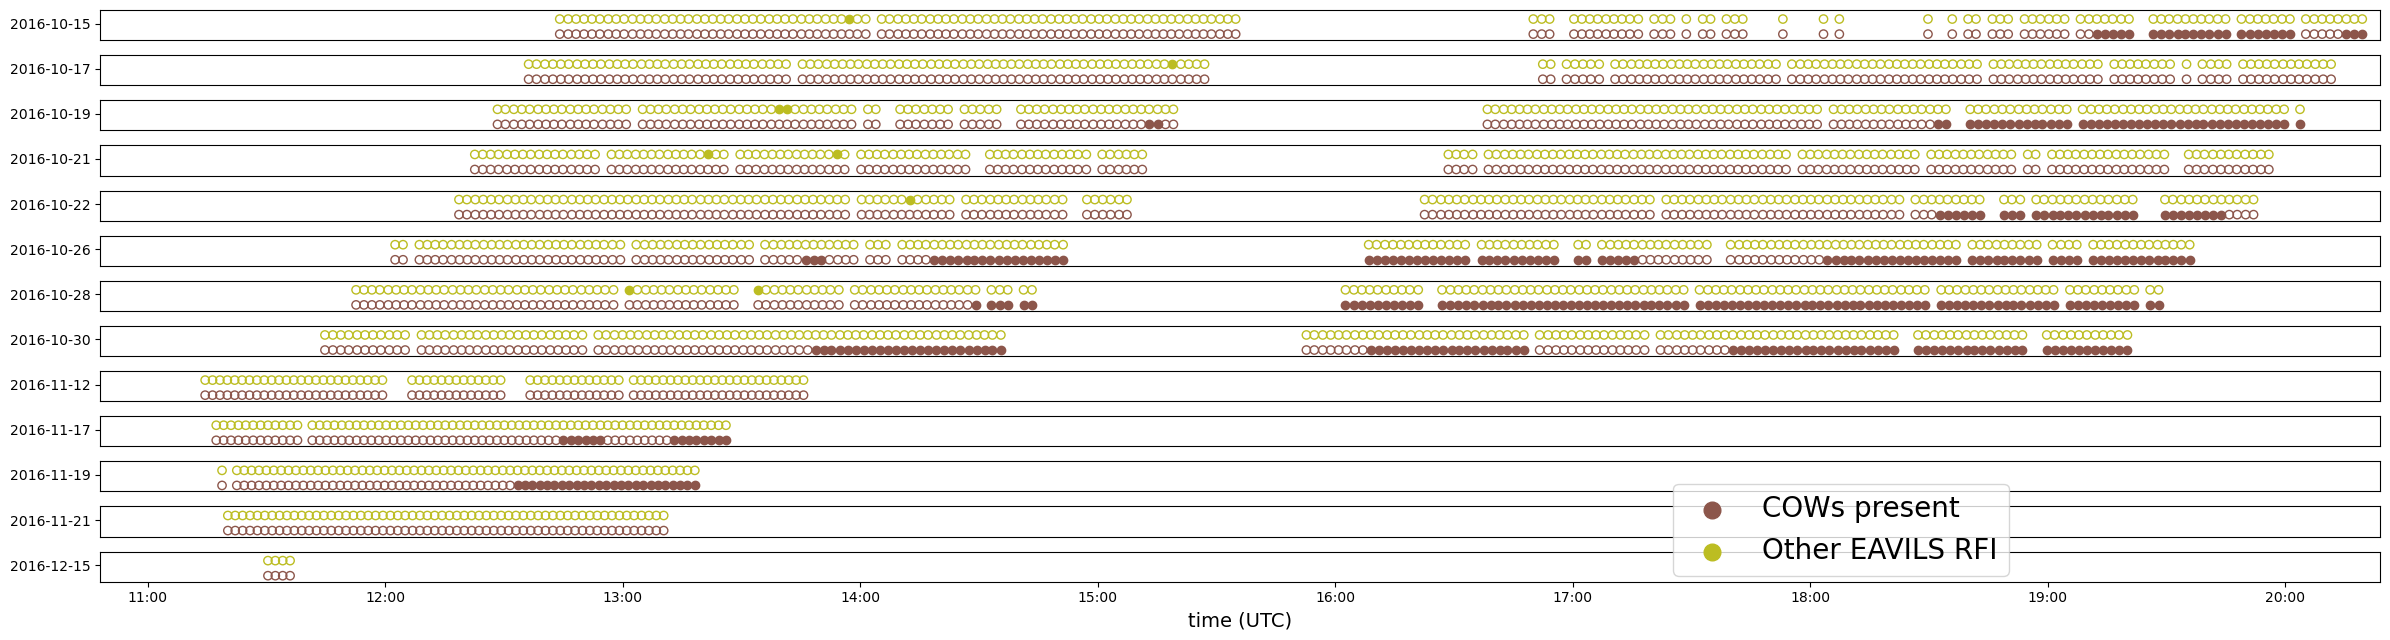

In [17]:
cows_df = pd.read_csv("testing_tutorial/all_processed_cows_data.csv")
cows_df['non cow EAVILS event '] = cows_df['non cow EAVILS event '].fillna(0)

cows_df['Obsid'] = cows_df['Obsid'].astype(str)
times = ['11:00',
 '12:00',
 '13:00',
 '14:00',
 '15:00',
 '16:00',
 '17:00',
 '18:00',
 '19:00',
 '20:00']


mjds = []
for time in cows_df["Obsid"]:
    mjds.append(Time(time, format="gps").mjd)

cows_df["mjd"] = mjds

int_mjds = [np.floor(i) for i in mjds]
days = Time(int_mjds, format='mjd')
obsids = np.array(cows_df["Obsid"])


batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*.5))


if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        
        index = np.sum(batchsizes[:i]) + j

       
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
        

           

        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y , **cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y+.5 , **non_cows_kwargs) # other EAVILS events

    ax[i].set_ylim(0.7, 1.7)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]])
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times)
plt.xlabel('time (UTC)', fontsize=14)

cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='COWs present')

non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='Other EAVILS RFI')



fig.legend(handles=[cows_dot,non_cows_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()



We can see here that there is a lot of contaminated data. Let's take data from a night without manually flagged COWs, 10-17-2016, and use that as an estimate for what the standard deviation of the pol-subtracted metric should be for each channel and sky field. Note that we'll also need to exclude any obs IDs that were tagged as containing non-COW-like RFI that EAVILS sees but SSINS doesn't. While the more data the better, a few pointings worth of data should be enough to establish our baseline estimate. These pointings do not have to be from the same night. Here we use three for each sky field. We use the central three pointings, (-1, 0, 1). This avoids the non-cow EAVIL event seen towards the end of 10-17 EOR0 (first section of data on that night).

We will also pre-filter any SSINS-flagged data in our pandas query.

In [18]:
#Picking lists and pointings for each sky field
#                   <sky field>:(<list title>, (<pointigns>)
good_source_dict = {'EOR0':('10-17-2016-EOR0',(-1,0,1)),'EOR1':('10-17-2016-EOR1',(-1,0,1))}


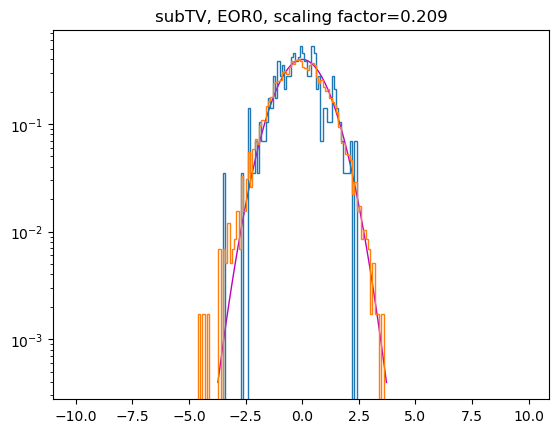

subTV 0.20931512180667902


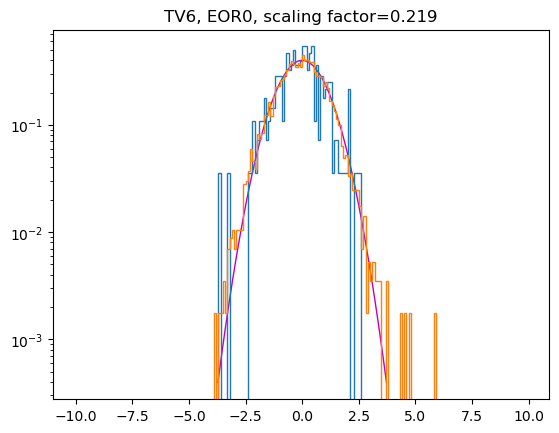

TV6 0.2192787445707703


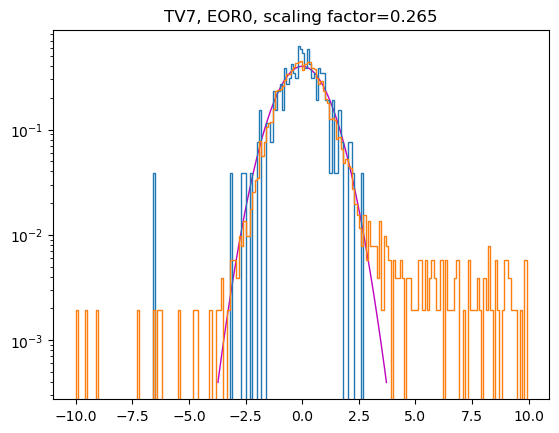

TV7 0.2653491476933758


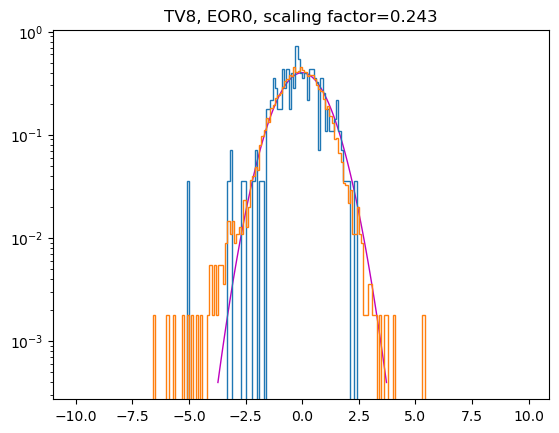

TV8 0.24263422139776053


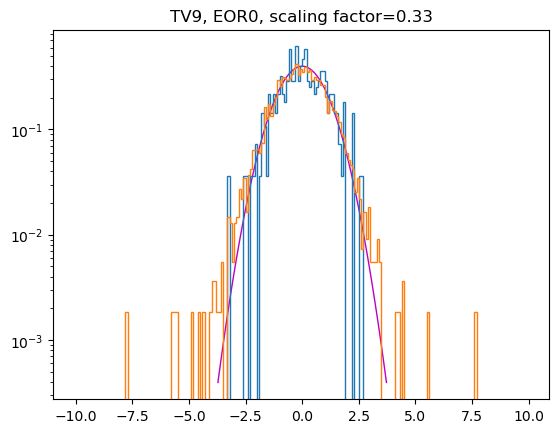

TV9 0.32971958100060994


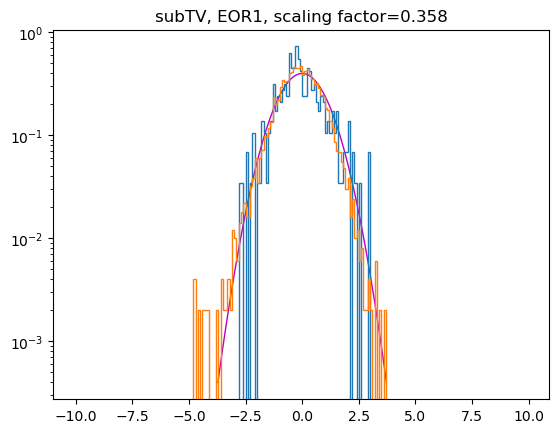

subTV 0.35773241514626153


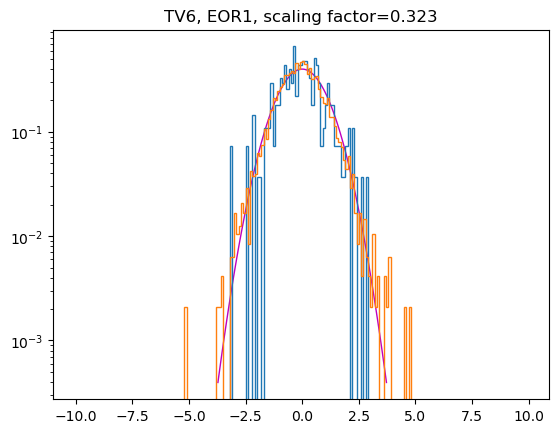

TV6 0.3231792363421625


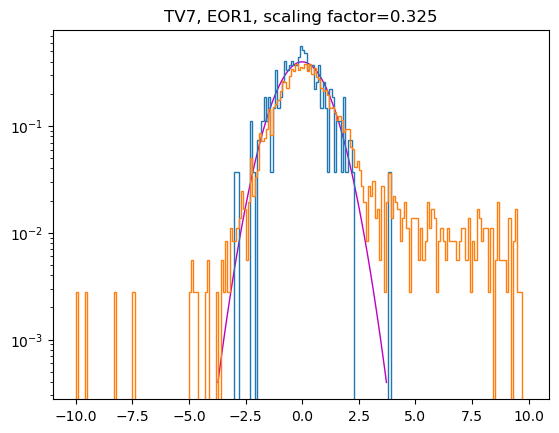

TV7 0.3245616340495682


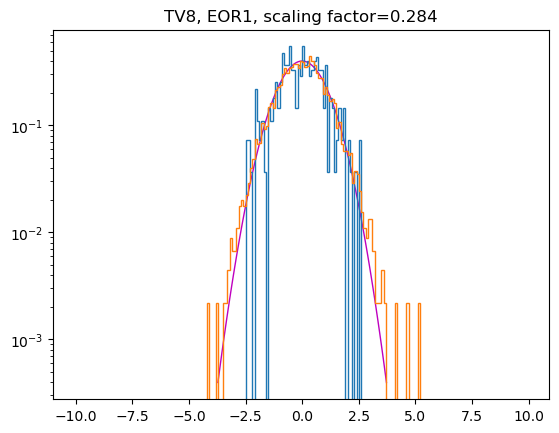

TV8 0.28399207341676563


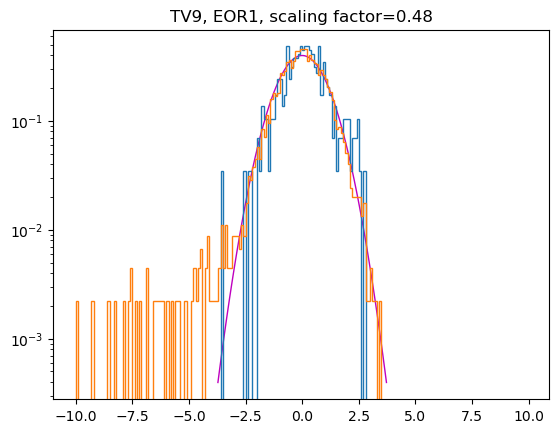

TV9 0.48003170882367896


In [19]:
initial_estimated_pol_sub_stdv= {sky_field:{} for sky_field in sky_field_list}



for sky_field in sky_field_list:
    for freq_range in sorted_freq_ranges:
        
        good_source_list,good_pointings = good_source_dict[sky_field]
        good_pointings = [str(i) for i in good_pointings]
        q_str_add = '['+','.join(good_pointings)+']'
        query_string_clean = f'source_list==\'{good_source_list}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing=={q_str_add}'
        
        pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
        scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
        
        initial_estimated_pol_sub_stdv[sky_field][freq_range] = scaling

        
        pol_sub_series = datafr.query(f'{'sky_field'}==\'{sky_field}\' & {'freq_range'}==\'{freq_range}\' & {'SSINS_flagged'}=={False}')['pol_sub']
        channel_dof = dof_ref_dict[freq_range]
       
    
        plt.yscale('log')
        x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                    scipy.stats.norm.ppf(0.9999,scale=1), 100)
        plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                'm-', lw=1, alpha=1, label='standard normal pdf')
        plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')
        
        plt.hist((pol_sub_series)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')


        plt.title(f'{freq_range}, {sky_field}, scaling factor={np.round(scaling,3)}')
        plt.show()
        
        print(freq_range,scaling)
    

Here we have plotted our hand-chosen "clean" data in blue and all data for that frequency range and sky field in orange, with both histograms rescaled using the estimated standard deviation from the clean data, and a standard normal distribution is shown in purple.  We get the following initial estimates for the standard deviation for each field/channel combo:

In [20]:
initial_estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.20931512180667902,
  'TV6': 0.2192787445707703,
  'TV7': 0.2653491476933758,
  'TV8': 0.24263422139776053,
  'TV9': 0.32971958100060994},
 'EOR1': {'subTV': 0.35773241514626153,
  'TV6': 0.3231792363421625,
  'TV7': 0.3245616340495682,
  'TV8': 0.28399207341676563,
  'TV9': 0.48003170882367896}}

Note that the TV9 channel has a markedly higher standard deviation. This is expected, because fewer frequencies are present in that channel within the frequency range the MWA is observing at for this dataset. Thus, fewer values go into the calculation of the variance for each measurement, and so the distribution of variances is wider, and thus the difference between variances between polarizations tends to be higher!

## Here we establish a threshold for flagging
 We base this on some simple assumptions on what we want our false positive rate to be per pointing, and how many data points we can expect per pointing. This is a flexible threshold

In [21]:
scipy.stats.norm.isf(.001/(5*100)) #False positive rate/(num_freq_channels * approx number of meas. per pointing)

4.611382362302668

In [22]:
threshold = 4.61

With our initial estimate of the standard deviation for the pol-subtracted metric in mind, we'd like to incorporate more data into our estimate. We thus use our initial estimate as a basis for identifying any pointing that has at least one measurement cross our predetermined threshold in a given frequency range. This is a conservative way to make sure our data is likely to be contamination free. We then get a new estimate of our standard deviation for each pol-subtracted distribution, check against the threshold again, and repeat until our estimates don't change.

iterations: 0
EOR0 subTV estimate shifted by 0.01256624470206455
EOR0 TV6 estimate shifted by 0.004767131927254531
EOR0 TV7 estimate shifted by -0.023158007234548916
EOR0 TV8 estimate shifted by -0.008181408039742571
EOR0 TV9 estimate shifted by 0.030903106502890465
EOR1 subTV estimate shifted by -0.027621784489941015
EOR1 TV6 estimate shifted by -0.005597626822667734
EOR1 TV7 estimate shifted by 0.007627663666683826
EOR1 TV8 estimate shifted by 0.01384935115040542
EOR1 TV9 estimate shifted by -0.02331662757087588
{'EOR0': {'subTV': 0.22188136650874357, 'TV6': 0.22404587649802482, 'TV7': 0.2421911404588269, 'TV8': 0.23445281335801796, 'TV9': 0.3606226875035004}, 'EOR1': {'subTV': 0.3301106306563205, 'TV6': 0.31758160951949477, 'TV7': 0.33218929771625205, 'TV8': 0.29784142456717105, 'TV9': 0.4567150812528031}}
iterations: 1
EOR0 subTV estimate shifted by 0.0
EOR0 TV6 estimate shifted by 0.0
EOR0 TV7 estimate shifted by 0.0
EOR0 TV8 estimate shifted by 0.0
EOR0 TV9 estimate shifted by 0.

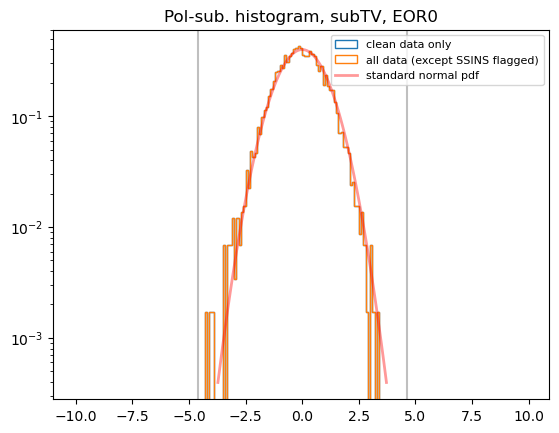

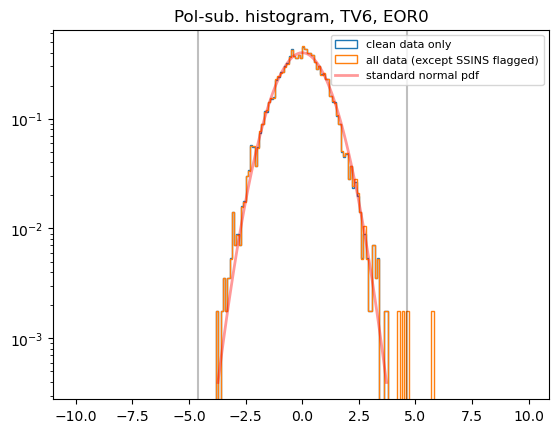

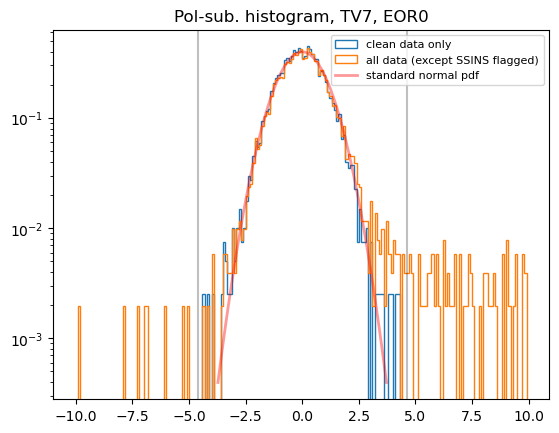

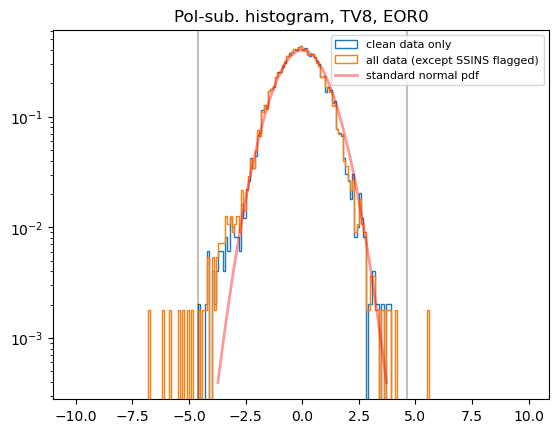

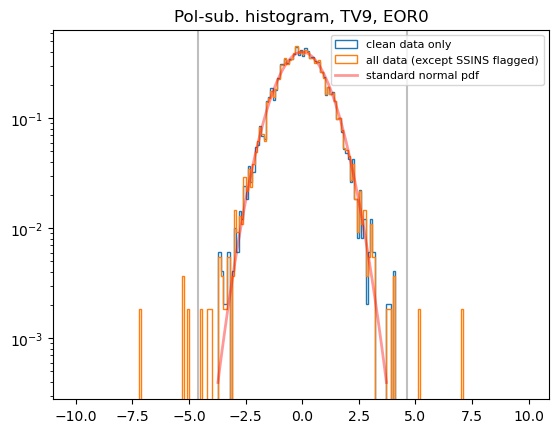

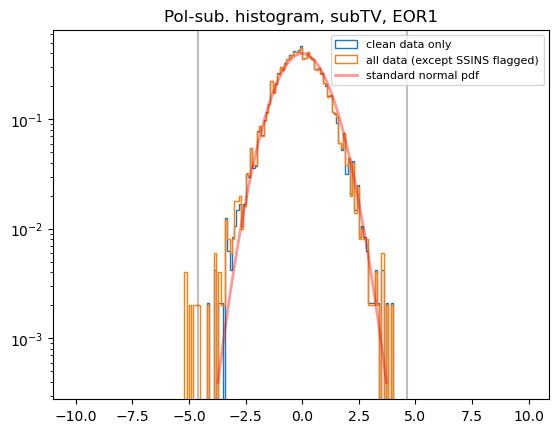

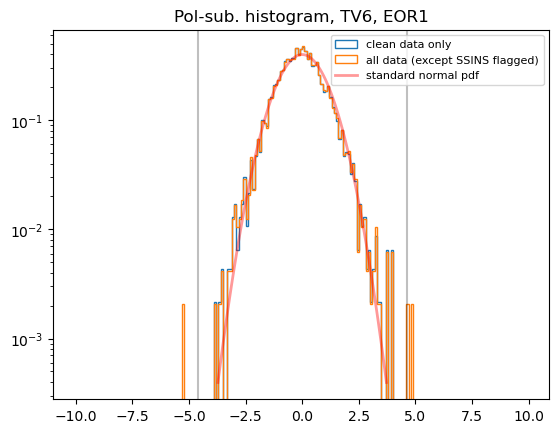

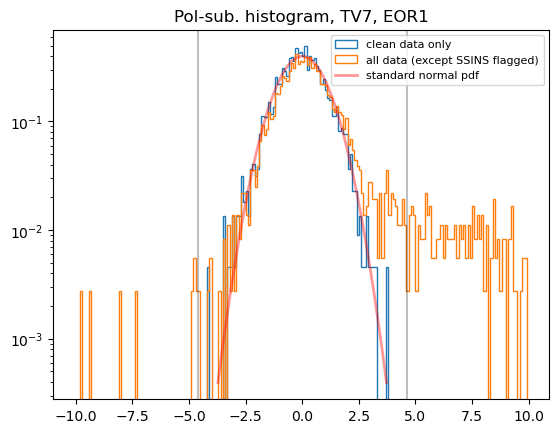

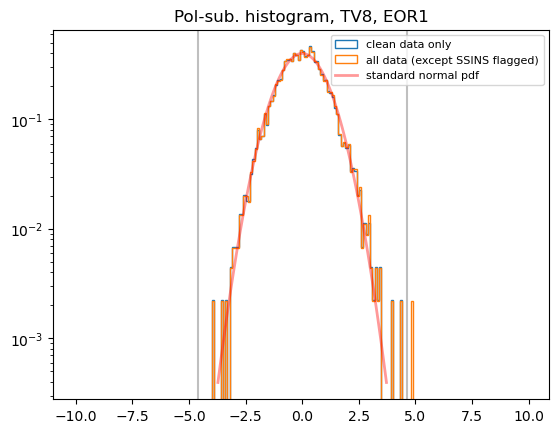

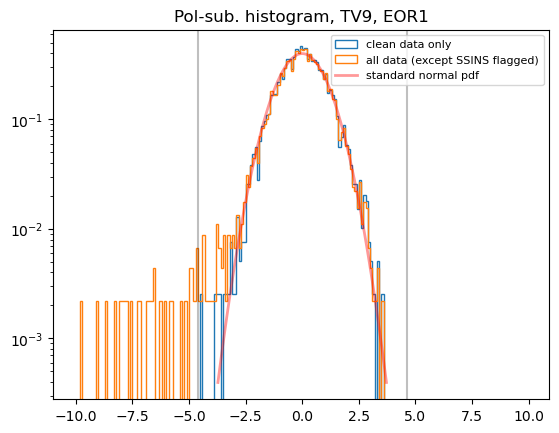

In [23]:
iteration_count=0

datafr['pointing_flagged'] = False #This should already be true, but ensures it's the case

estimated_pol_sub_stdv = copy.deepcopy(initial_estimated_pol_sub_stdv)
while True:
    print('iterations:',iteration_count)
    prev_estimated_pol_sub_stdv = copy.deepcopy(estimated_pol_sub_stdv)
    
    for source_list in np.unique(datafr.source_list):
        
        sky_field = sky_field_list_association[source_list]

        for pointing in np.unique(datafr.pointing):
            for freq_range in sorted_freq_ranges:
                query_string = f'sky_field==\'{sky_field}\' & source_list==\'{source_list}\' & pointing=={pointing} & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                sub_series = datafr.query(query_string)['pol_sub']
                estimated_stdv = estimated_pol_sub_stdv[sky_field][freq_range]
                outliers = np.abs(sub_series)>(estimated_stdv*threshold)
    
                if np.sum(outliers)>0:
                    flag_pointing=True
                else:
                    flag_pointing=False
                if flag_pointing:
                    flagged_indices = datafr.query(query_string).index
                    datafr.loc[flagged_indices,'pointing_flagged'] = True
    
    
    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
            pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
    
            scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
            
            estimated_pol_sub_stdv[sky_field][freq_range] = scaling

    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            print(sky_field,freq_range,'estimate shifted by', estimated_pol_sub_stdv[sky_field][freq_range] - prev_estimated_pol_sub_stdv[sky_field][freq_range])
    print(estimated_pol_sub_stdv) 
    if estimated_pol_sub_stdv==prev_estimated_pol_sub_stdv:    
        for sky_field in sky_field_list:
            for freq_range in sorted_freq_ranges:
                query_string_all = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                pol_sub_series_all = datafr.query(query_string_all)['pol_sub']
                
                query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
                pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
                plt.yscale('log')
                
                scaling = estimated_pol_sub_stdv[sky_field][freq_range]
                
                plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='clean data only')
                plt.hist((pol_sub_series_all)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='all data (except SSINS flagged)')
                plt.vlines([-threshold,threshold],ymin=0,ymax=1,color='black',alpha=.25)
                
                x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                            scipy.stats.norm.ppf(0.9999,scale=1), 100)
                plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                        'r-', lw=2, alpha=0.4, label='standard normal pdf')
                plt.title(f'Pol-sub. histogram, {freq_range}, {sky_field}')
                plt.legend( prop={'size': 8})
                plt.show()
        break
    iteration_count+=1
           

We get the following estimate for standard deviations. We save it out to a yaml file.

In [24]:
estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.22188136650874357,
  'TV6': 0.22404587649802482,
  'TV7': 0.2421911404588269,
  'TV8': 0.23445281335801796,
  'TV9': 0.3606226875035004},
 'EOR1': {'subTV': 0.32745058949911066,
  'TV6': 0.31758160951949477,
  'TV7': 0.33218929771625205,
  'TV8': 0.29784142456717105,
  'TV9': 0.4567150812528031}}

In [25]:
#Yaml is unhappy with numpy floats, so we fix this here
for sky_field,sub_dict in estimated_pol_sub_stdv.items():
        for freq_range,stdv in sub_dict.items():
            estimated_pol_sub_stdv[sky_field][freq_range] = float(stdv)
with open('testing_tutorial/2016_fall_pol_sub_stdv.yml', 'w') as file:
    for sky_field,sub_dict in estimated_pol_sub_stdv.items():
        for freq_range,stdv in sub_dict.items():
            estimated_pol_sub_stdv[sky_field][freq_range] = float(stdv)
            
        
    yaml.safe_dump(estimated_pol_sub_stdv, file, default_flow_style=False, sort_keys=False) 

# Flagging data

We load in this estimated standard deviation for the pol-subtracted metric generated above here.

In [26]:
with open('testing_tutorial/2016_fall_pol_sub_stdv.yml', 'r') as file:
    estimated_pol_sub_stdv = yaml.safe_load(file) # Use safe_load for security

We add this estimated standard deviation to our dataframe and generate flags in this next step.

In [35]:
datafr= EAVILS_processing.add_pol_sub_stdv(datafr,estimated_pol_sub_stdv,threshold)

In [36]:
datafr

,obs_id,sky_field,t_block_ind,pointing,pol_sub,SSINS_flagged,pol_sub_flagged,pointing_flagged,source_list,variance_XX,variance_YY,variance_XY,variance_YX,freq_range,pol_sub_stdv
0,1160570624,EOR0,0,-3,0.056206,False,False,False,10-15-2016-EOR0,0.930479,0.874273,1.165698,0.805516,subTV,0.221881
1,1160570624,EOR0,1,-3,-0.116945,False,False,False,10-15-2016-EOR0,0.833844,0.950789,0.945145,0.821371,subTV,0.221881
2,1160570624,EOR0,2,-3,-0.243281,False,False,False,10-15-2016-EOR0,0.796385,1.039666,0.869899,0.716439,subTV,0.221881
3,1160570624,EOR0,3,-3,0.256630,False,False,False,10-15-2016-EOR0,0.952791,0.696161,0.715759,0.611471,subTV,0.221881
4,1160570624,EOR0,4,-3,-0.009160,False,False,False,10-15-2016-EOR0,0.998318,1.007478,0.792041,1.004227,subTV,0.221881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58970,1165836936,EOR0,2,2,-2.370354,True,True,False,12-15-2016-EOR0,7.224489,9.594843,9.950595,9.690604,TV9,0.360623
58971,1165836936,EOR0,3,2,-0.423316,True,False,False,12-15-2016-EOR0,9.418619,9.841935,10.056358,10.784077,TV9,0.360623
58972,1165836936,EOR0,4,2,-1.149243,True,False,False,12-15-2016-EOR0,10.154446,11.303689,11.165458,9.820784,TV9,0.360623
58973,1165836936,EOR0,5,2,-3.124421,True,True,False,12-15-2016-EOR0,8.476300,11.600721,11.029293,10.066346,TV9,0.360623


In [37]:
per_pointing_stats=EAVILS_processing.find_per_pointing_stats(datafr=datafr,shape_dict=shape_dict,list_titles=list_titles,threshold=threshold)


/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/elillesk/miniconda3/envs/my_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/elillesk/miniconda3/envs/my_env/lib/python3.1

In [38]:
for list_title in per_pointing_stats.keys():
    print(list_title,'===============================')
    
    for pointing in per_pointing_stats[list_title]['subTV'].keys():
        print('               ',pointing,'____________')
        for freq_range in sorted_freq_ranges:
            local_flagged_count = per_pointing_stats[list_title][freq_range][pointing]['flagged_count']
            if local_flagged_count>0:
                print('                   ',freq_range,':',local_flagged_count)

10-15-2016-EOR0 ===============================
                -3 ____________
                -2 ____________
                -1 ____________
                    TV7 : 6
                0 ____________
                1 ____________
                2 ____________
                    TV7 : 5
                    TV9 : 1
                3 ____________
10-15-2016-EOR1 ===============================
                -3 ____________
                    subTV : 2
                -2 ____________
                -1 ____________
                0 ____________
                1 ____________
                    TV7 : 18
                2 ____________
                    TV7 : 19
                3 ____________
                    TV7 : 27
                    TV9 : 9
10-17-2016-EOR0 ===============================
                -3 ____________
                -2 ____________
                -1 ____________
                    TV7 : 1
                0 ____________
                1 ____________
 